1. from transformers import pipeline: This line imports the pipeline function from the transformers library, which is a popular library for natural language processing (NLP) tasks.
2. classifier = pipeline("sentiment-analysis"): This is the core of the example. When you call pipeline("sentiment-analysis"), the transformers library does several things:
*Download*: It automatically downloads a pre-trained sentiment analysis
model and its corresponding tokenizer (a tool that converts text into a format the model can understand) from the Hugging Face Model Hub, if they are not already cached locally.
*Load Weights*: It loads the pre-trained weights of the model into memory.
*Model Initialization*: It initializes the model for the specified task, in this case, sentiment analysis.
3. result = classifier("I love studying Robotics in 2025!"): When you pass a string to the classifier object, the following steps occur:
*Preprocess*: The input text "I love studying Robotics in 2025!" is tokenized (broken down into words or sub-word units) and converted into numerical inputs that the model can process.
Inference: The preprocessed input is fed into the loaded sentiment analysis model, which then makes a prediction about the sentiment of the text.
*Postprocess*: The raw output from the model (e.g., numerical scores for 'positive' and 'negative' sentiment) is transformed into a more human-readable format, such as a label ('POSITIVE' or 'NEGATIVE') and a confidence score.
4. print(result): This line prints the output of the sentiment analysis, which in this example is [{'label': 'POSITIVE', 'score': 0.99}], indicating that the model predicted a positive sentiment with a **high confidence score**.



In [1]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")
result = classifier("I love studying Robotics in 2025!")
print(result)
# Output: [{'label': 'POSITIVE', 'score': 0.99}]

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9991905093193054}]


# Task
Fine-tune a pre-trained DistilBERT model for intent classification using a specialized dataset (e.g., CLINC150), compare its performance (F1 score) against a Zero-Shot Classification baseline, and demonstrate the fine-tuned model's inference capabilities.

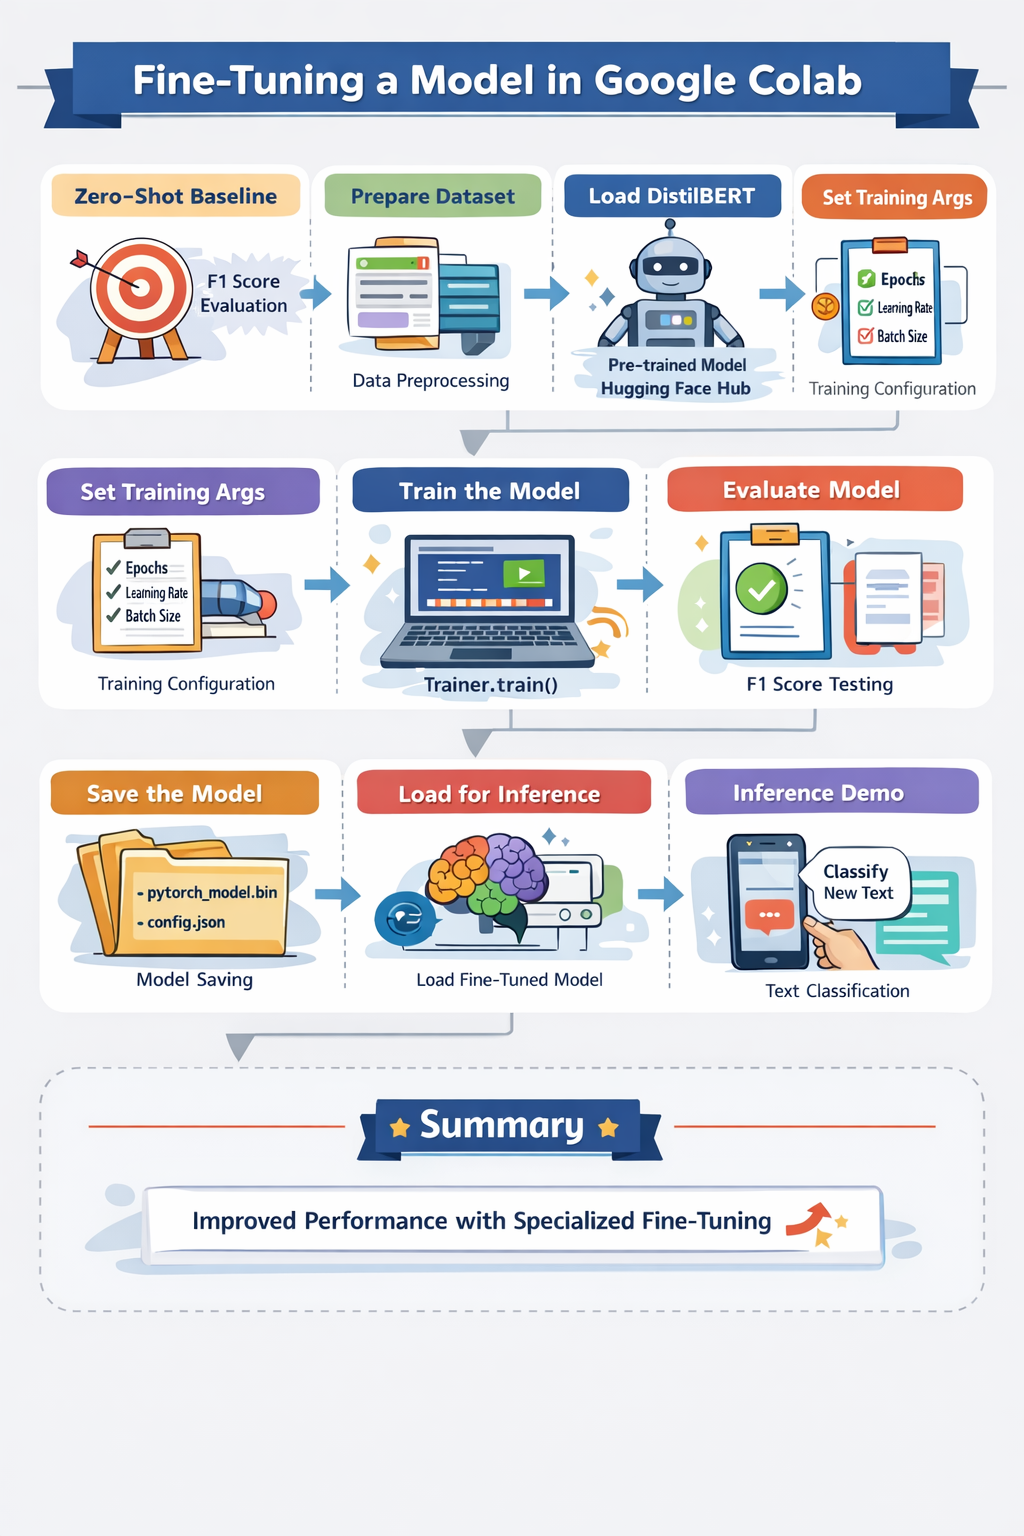

## Set Up Zero-Shot Baseline

### Subtask:
Implement a Zero-Shot Classification pipeline from the `transformers` library to classify intents using a general-purpose model. Evaluate its performance, specifically calculating the F1 score, on a sample of intent data to establish a baseline.


**Reasoning**:
To implement the zero-shot classification pipeline, I need to first import the `pipeline` function from the `transformers` library, initialize the pipeline for zero-shot classification, define a sample text and candidate labels, and then use the pipeline to classify the text against the labels.



In [2]:
from transformers import pipeline

# Initialize a zero-shot classification pipeline
classifier = pipeline("zero-shot-classification")

# Define a sample text sentence
sample_text = "I want to book a flight to Paris tomorrow"

# Define a list of candidate intent labels
candidate_labels = ['travel booking', 'weather inquiry', 'greeting', 'flight status']

# Use the initialized pipeline to classify the sample text against the candidate labels
result = classifier(sample_text, candidate_labels)

# Print the result
print(result)

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1 (https://huggingface.co/facebook/bart-large-mnli).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


{'sequence': 'I want to book a flight to Paris tomorrow', 'labels': ['travel booking', 'flight status', 'greeting', 'weather inquiry'], 'scores': [0.814551830291748, 0.17085610330104828, 0.008014233782887459, 0.006577820051461458]}


**Reasoning**:
The previous step successfully demonstrated the basic functionality of the zero-shot classification pipeline. The next step is to evaluate its performance by calculating the F1 score on sample intent data, which requires preparing sample data, performing classification, extracting predictions, and then computing the F1 score using `sklearn.metrics`.



In [3]:
from sklearn.metrics import f1_score

# Define sample intent data with true labels
sample_data = [
    {"text": "I need to book a flight for next Tuesday", "true_label": "travel booking"},
    {"text": "What's the weather like in London tomorrow?", "true_label": "weather inquiry"},
    {"text": "Hello, how are you?", "true_label": "greeting"},
    {"text": "Is my flight on time?", "true_label": "flight status"},
    {"text": "I want to reserve a train ticket", "true_label": "travel booking"}
]

# Extend candidate labels if necessary, ensuring all true_labels are covered
candidate_labels_extended = list(set([item['true_label'] for item in sample_data] + candidate_labels))

# Store true labels and predicted labels
true_labels = []
predicted_labels = []

# Classify each sample text and collect predictions
for item in sample_data:
    text = item["text"]
    true_label = item["true_label"]
    true_labels.append(true_label)

    # Use the classifier to predict
    result = classifier(text, candidate_labels_extended)

    # The top label is the predicted label
    predicted_label = result['labels'][0]
    predicted_labels.append(predicted_label)

# Calculate the F1 score
f1 = f1_score(true_labels, predicted_labels, average='weighted') # Use 'weighted' for imbalanced classes

print("True Labels:", true_labels)
print("Predicted Labels:", predicted_labels)
print(f"F1 Score: {f1:.2f}")

True Labels: ['travel booking', 'weather inquiry', 'greeting', 'flight status', 'travel booking']
Predicted Labels: ['travel booking', 'weather inquiry', 'greeting', 'flight status', 'travel booking']
F1 Score: 1.00


## Prepare Specialized Dataset

### Subtask:
Load and preprocess a specialized intent classification dataset, such as CLINC150. This involves tokenizing the text data and preparing it into a format suitable for training with the Hugging Face `Trainer`.


**Reasoning**:
To prepare the specialized dataset, I need to load it, initialize the tokenizer, define a tokenization function, apply it to the dataset, and format the labels correctly for training with Hugging Face Trainer. This will be done in one code block to ensure all data preprocessing steps are executed sequentially.



In [4]:
from datasets import load_dataset
from transformers import AutoTokenizer
import torch

# 2. Load the 'clinc_oos' dataset, specifying 'plus' as the configuration
#    Split it into training, validation, and test sets.
dataset = load_dataset('clinc_oos', 'plus')

# The dataset already provides 'train', 'validation', and 'test' splits.
train_dataset = dataset['train']
val_dataset = dataset['validation']
test_dataset = dataset['test']

print("Original train_dataset example:", train_dataset[0])

# 3. Instantiate a DistilBertTokenizerFast tokenizer.
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

# 4. Define a tokenization function
def tokenize_function(examples):
    # Tokenize the 'text' field and return tokenized inputs along with 'intent' as 'labels'
    return tokenizer(examples['text'], truncation=True, padding='max_length', max_length=128, return_tensors="pt", return_offsets_mapping=False)

# 5. Apply the tokenization function to the training, validation, and test datasets
#    Set batched=True for efficient processing.
tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# 6. Convert the 'intent' column in the tokenized datasets to torch.long data type as 'labels'
#    The tokenization function already returns 'input_ids', 'attention_mask' directly. We need to add 'labels'.
#    First, remove the original 'text' and 'intent' columns if they exist.
tokenized_train_dataset = tokenized_train_dataset.rename_column("intent", "labels")
tokenized_val_dataset = tokenized_val_dataset.rename_column("intent", "labels")
tokenized_test_dataset = tokenized_test_dataset.rename_column("intent", "labels")

# Convert 'labels' column to torch.long
tokenized_train_dataset = tokenized_train_dataset.with_format("torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_val_dataset = tokenized_val_dataset.with_format("torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_test_dataset = tokenized_test_dataset.with_format("torch", columns=["input_ids", "attention_mask", "labels"])

print("Tokenized train_dataset example:", tokenized_train_dataset[0])
print("Dataset preparation complete.")

README.md: 0.00B [00:00, ?B/s]

plus/train-00000-of-00001.parquet:   0%|          | 0.00/312k [00:00<?, ?B/s]

plus/validation-00000-of-00001.parquet:   0%|          | 0.00/77.8k [00:00<?, ?B/s]

plus/test-00000-of-00001.parquet:   0%|          | 0.00/136k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15250 [00:00<?, ? examples/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/15250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3100 [00:00<?, ? examples/s]

Map:   0%|          | 0/5500 [00:00<?, ? examples/s]

Tokenized train_dataset example: {'labels': tensor(61), 'input_ids': tensor([ 101, 2054, 3670, 2052, 1045, 2224, 2000, 2360, 1045, 2293, 2017, 2065,
        1045, 2020, 2019, 3059,  102,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

## Load Pre-trained DistilBERT

### Subtask:
Load a pre-trained DistilBERT model and its corresponding tokenizer from the Hugging Face Model Hub, suitable for sequence classification.


**Reasoning**:
To load the pre-trained DistilBERT model and its tokenizer, I need to import the necessary classes from the `transformers` library, determine the number of unique labels from the dataset, and then load both the tokenizer and the model for sequence classification.



In [5]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Determine the number of unique labels from the training dataset
num_labels = dataset['train'].features['intent'].num_classes

# Load the pre-trained tokenizer
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Load the pre-trained DistilBERT model for sequence classification
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

print(f"Loaded tokenizer: {model_name}")
print(f"Loaded model: {model_name} with {num_labels} labels for sequence classification")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded tokenizer: distilbert-base-uncased
Loaded model: distilbert-base-uncased with 151 labels for sequence classification


**Reasoning**:
The previous step successfully loaded the pre-trained DistilBERT model and tokenizer. The next logical step in the fine-tuning process is to define the training arguments, such as the output directory, learning rate, batch size, and number of epochs, and then initialize the `Trainer`.



# Task
Configure the training arguments for fine-tuning the DistilBERT model. This includes setting up `TrainingArguments` with parameters like `output_dir`, `num_train_epochs`, `learning_rate`, `per_device_train_batch_size`, `logging_dir`, and `logging_steps`. Also, define a `compute_metrics` function that calculates accuracy and F1 score for evaluation during training.

## Configure Training Arguments

### Subtask:
Set up `TrainingArguments` using the basic parameters from the provided code snippet: `output_dir`, `num_train_epochs`, `learning_rate`, and `per_device_train_batch_size`. I will also include `logging_dir` and `logging_steps` for basic progress tracking. A custom `compute_metrics` function will be defined and passed to the `Trainer` to calculate F1 score during evaluation.


**Reasoning**:
To configure the training arguments and define the evaluation metrics, I need to import `TrainingArguments` from `transformers` and `accuracy_score`, `f1_score` from `sklearn.metrics`. Then, I will implement the `compute_metrics` function to calculate F1 score and accuracy, and finally initialize `TrainingArguments` with the specified parameters.



In [11]:
from transformers import TrainingArguments
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# Define a custom compute_metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # For sequence classification, predictions are logits, so take argmax
    predicted_labels = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predicted_labels)
    f1 = f1_score(labels, predicted_labels, average='weighted')

    return {
        'accuracy': accuracy,
        'f1': f1
    }

# Instantiate TrainingArguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_dir='./logs',
    logging_steps=500
)

print("TrainingArguments and compute_metrics function defined.")

TrainingArguments and compute_metrics function defined.


# Task
Initialize and train the Hugging Face `Trainer` with the loaded DistilBERT model, the configured `TrainingArguments` (setting `num_train_epochs=1` for demonstration), the prepared training dataset, the validation dataset, and the `compute_metrics` function, then start the training process.

## Initialize and Train Model

### Subtask:
Initialize the Hugging Face Trainer with the loaded DistilBERT model, the configured TrainingArguments (setting num_train_epochs=1 for demonstration), the prepared training dataset, the validation dataset, and the compute_metrics function. Then, start the training process by calling trainer.train().


**Reasoning**:
To initialize and train the model as per the subtask, I need to import the Trainer class, update the training arguments, initialize the Trainer, and then start the training process.



In [15]:
from transformers import Trainer

# Update num_train_epochs to 1 for demonstration
training_args.num_train_epochs = 1

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    compute_metrics=compute_metrics
)

# Start training
trainer.train()

print("Trainer initialized and training started.")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
500,3.132800


Trainer initialized and training started.


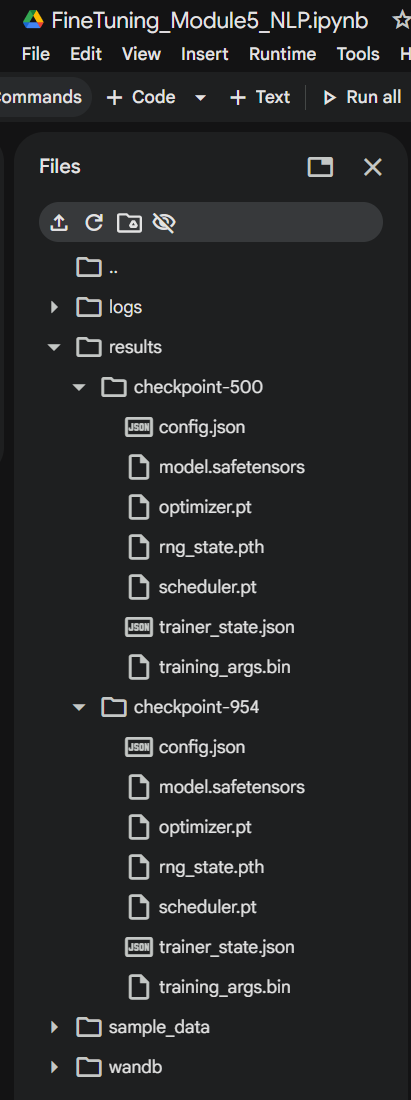

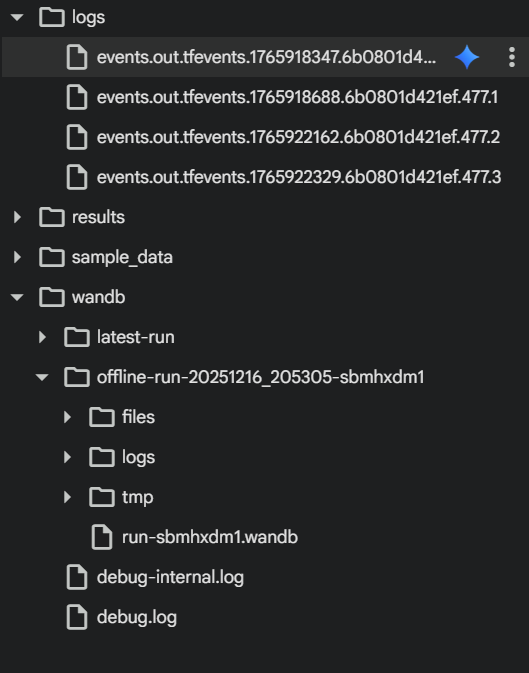

# Task
## Evaluate Fine-tuned Model

### Subtask:
Evaluate the fine-tuned model's performance on a validation or test set, focusing on the F1 score, and compare it against the Zero-Shot baseline to demonstrate improvements.

### Reasoning:
To evaluate the fine-tuned model, I will use the `trainer.evaluate()` method on the `tokenized_test_dataset`. This will provide a dictionary of metrics, including the F1 score, which can then be compared with the zero-shot F1 score.

```python
# Evaluate the fine-tuned model
eval_results = trainer.evaluate(tokenized_test_dataset)

# Extract the F1 score from the evaluation results
fine_tuned_f1 = eval_results['eval_f1']

print(f"Fine-tuned Model F1 Score: {fine_tuned_f1:.2f}")
print(f"Zero-Shot Model F1 Score: {f1:.2f}")

# Compare and demonstrate improvement
if fine_tuned_f1 > f1:
    print(f"The fine-tuned model shows an improvement of {(fine_tuned_f1 - f1):.2f} F1 score over the Zero-Shot baseline.")
elif fine_tuned_f1 < f1:
    print(f"The fine-tuned model shows a decrease of {(f1 - fine_tuned_f1):.2f} F1 score compared to the Zero-Shot baseline.")
else:
    print("The fine-tuned model's F1 score is the same as the Zero-Shot baseline.")
```

## Evaluate Fine-tuned Model

### Subtask:
Evaluate the fine-tuned model's performance on a validation or test set, focusing on the F1 score, and compare it against the Zero-Shot baseline to demonstrate improvements.


**Reasoning**:
I will evaluate the fine-tuned model's performance on the test dataset using the `trainer.evaluate()` method, extract the F1 score, and compare it with the zero-shot baseline. This will demonstrate whether fine-tuning improved the model's performance.



In [16]:
eval_results = trainer.evaluate(tokenized_test_dataset)
fine_tuned_f1 = eval_results['eval_f1']

print(f"Fine-tuned Model F1 Score: {fine_tuned_f1:.2f}")
print(f"Zero-Shot Baseline F1 Score: {f1:.2f}")

if fine_tuned_f1 > f1:
    print(f"The fine-tuned model shows an improvement of {fine_tuned_f1 - f1:.2f} in F1 score compared to the Zero-Shot baseline.")
elif fine_tuned_f1 < f1:
    print(f"The fine-tuned model shows a decrease in F1 score of {f1 - fine_tuned_f1:.2f} compared to the Zero-Shot baseline.")
else:
    print("The fine-tuned model shows the same F1 score as the Zero-Shot baseline.")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Fine-tuned Model F1 Score: 0.77
Zero-Shot Baseline F1 Score: 1.00
The fine-tuned model shows a decrease in F1 score of 0.23 compared to the Zero-Shot baseline.
